# Importing Libraries and Modules

In [85]:
# Imports 
import os
import sys
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
import json
import numpy as np
%matplotlib inline

In [220]:
# Module Imports
# Add the scripts directory to the Python path
sys.path.append(os.path.abspath("../scripts"))

# Import from script files directly (no 'scripts.' prefix)
from load_data import process_star_sample, save_processed_lightcurves
from star_catalog import stars
import importlib


import plot_utils  # the actual module
import inject_synthetic_flares  # the actual module
import lstm_flare_classifier
importlib.reload(plot_utils)
importlib.reload(inject_synthetic_flares)
importlib.reload(lstm_flare_classifier)

from plot_utils import plot_raw_lightcurves, plot_synthetic_lightcurves
from inject_synthetic_flares import inject_into_lightcurves
from lstm_flare_classifier import train_model, load_model, evaluate_model, predict_single_sequence

# Parameters for Pre-Processing

In [74]:
# -----------------------
# Parameters
# -----------------------
cadence = "short"          # 2-minute cadence
mission = "TESS"
author = "SPOC"
sector_constraint = None   # Use all sectors

output_raw_path = "../data/processed_lightcurves.pkl"
output_synthetic_path = "../data/synthetic_lightcurves.pkl"

# Fetching and Processing Lightcurves from MAST API

In [4]:
# Run Processing
print("Starting light curve processing...")

processed_lightcurves = process_star_sample(
    stars_dict=stars,
    cadence=cadence,
    mission=mission,
    author=author,
    sector_constraint=sector_constraint
)

Starting light curve processing...

Processing M-Dwarf stars...
TIC 117955697
Stored Sector 57 with 0 flares.
TIC 238302206
Stored Sector 57 with 0 flares.
TIC 257503361
Stored Sector 70 with 0 flares.
TIC 238407367


No data found for target "TIC 238407367".
No data found for target "TIC 238407367".


 No data found... skipping...
No valid data for TIC 238407367
TIC 293257611
Stored Sector 70 with 0 flares.
TIC 150784513


No data found for target "TIC 150784513".
No data found for target "TIC 150784513".


 No data found... skipping...
No valid data for TIC 150784513
TIC 29780677


...

Stored Sector 3 with 0 flares.
TIC 126999479
Stored Sector 17 with 0 flares.
TIC 397981427
Stored Sector 24 with 0 flares.
TIC 278774296


No data found for target "TIC 278774296".
No data found for target "TIC 278774296".


 No data found... skipping...
No valid data for TIC 278774296
TIC 400498945


No data found for target "TIC 400498945".
No data found for target "TIC 400498945".


 No data found... skipping...
No valid data for TIC 400498945
TIC 61573272
Stored Sector 17 with 0 flares.
TIC 400503418
Stored Sector 58 with 0 flares.
TIC 71852020
Stored Sector 58 with 1 flares.
TIC 293457962
Stored Sector 30 with 0 flares.
TIC 428772395
Stored Sector 58 with 0 flares.
TIC 285424422
Stored Sector 18 with 0 flares.
TIC 302620316
Stored Sector 52 with 0 flares.


In [5]:
# Save Output
save_processed_lightcurves(processed_lightcurves, filepath=output_raw_path)
print("Pipeline complete.")

Saved light curves to ../data/processed_lightcurves.pkl
Pipeline complete.


In [75]:
with open(output_raw_path, 'rb') as f:
    processed_lightcurves = pickle.load(f)

plot_raw_lightcurves(processed_lightcurves, output_dir="../data/figures/raw")
print("Plotting complete.")

Inside plot_raw_lightcurves function
TIC 117955697: Preparing plot...
TIC 117955697 (Sector 57): 0 flares detected.
Saved plot to ../data/figures/raw/TIC_117955697_Sector_57.png
TIC 238302206: Preparing plot...
TIC 238302206 (Sector 57): 0 flares detected.
Saved plot to ../data/figures/raw/TIC_238302206_Sector_57.png
TIC 257503361: Preparing plot...
TIC 257503361 (Sector 70): 0 flares detected.
Saved plot to ../data/figures/raw/TIC_257503361_Sector_70.png
TIC 293257611: Preparing plot...
TIC 293257611 (Sector 70): 0 flares detected.
Saved plot to ../data/figures/raw/TIC_293257611_Sector_70.png
TIC 29780677: Preparing plot...
TIC 29780677 (Sector 39): 2 flares detected.
Saved plot to ../data/figures/raw/TIC_29780677_Sector_39.png
TIC 83806907: Preparing plot...
TIC 83806907 (Sector 24): 0 flares detected.
Saved plot to ../data/figures/raw/TIC_83806907_Sector_24.png
TIC 194386500: Preparing plot...
TIC 194386500 (Sector 17): 0 flares detected.
Saved plot to ../data/figures/raw/TIC_194386

# Synthetic Flare Injection

In [125]:
# Generate new synthetic light curves with flare injections
synthetic_lightcurves = inject_into_lightcurves(
    processed_lightcurves,
    num_flares_range=(2, 7),         # Force at least one flare per star
    inject_in_gaps=True              # Randomly inject in or around gaps
)

# Save to disk
with open(output_synthetic_path, "wb") as f:
    pickle.dump(synthetic_lightcurves, f)

print("Synthetic flare injection complete")

!!!!TEST!!!
Synthetic flare injection complete


In [106]:
with open(output_synthetic_path, 'rb') as f:
    synthetic_lightcurves = pickle.load(f)
plot_synthetic_lightcurves(synthetic_lightcurves, "../data/figures/synthetic")

Saved synthetic flare plot: ../data/figures/synthetic/TIC_117955697_synthetic.png
Saved synthetic flare plot: ../data/figures/synthetic/TIC_238302206_synthetic.png
Saved synthetic flare plot: ../data/figures/synthetic/TIC_257503361_synthetic.png
Saved synthetic flare plot: ../data/figures/synthetic/TIC_293257611_synthetic.png
Saved synthetic flare plot: ../data/figures/synthetic/TIC_29780677_synthetic.png
Saved synthetic flare plot: ../data/figures/synthetic/TIC_83806907_synthetic.png
Saved synthetic flare plot: ../data/figures/synthetic/TIC_194386500_synthetic.png
Saved synthetic flare plot: ../data/figures/synthetic/TIC_369826081_synthetic.png
Saved synthetic flare plot: ../data/figures/synthetic/TIC_405608275_synthetic.png
Saved synthetic flare plot: ../data/figures/synthetic/TIC_405186527_synthetic.png
Saved synthetic flare plot: ../data/figures/synthetic/TIC_439992889_synthetic.png
Saved synthetic flare plot: ../data/figures/synthetic/TIC_242841582_synthetic.png
Saved synthetic fl

# LSTM Model Training and Evaluation

In [218]:
# Define Paths for run
run= "dropout02_earlystopping_focalloss2_nonflaring005_classweights_batch64_seq1200_stride600_printclass" # Change this string to test different models/hyperparameters/different processed data 

# Define hyperparameters
batch_size= 64
epochs= 10
learning_rate = 1e-3
seq_len= 1200
use_attention= False
hidden_size= 128
num_layers= 3
dropout=0.2

# Define Paths Based on Run
data_path = "../data/synthetic_lightcurves.pkl"  # Input dataset (most likely output_synthetic_path)
split_path = f"../models/splits_{run}.json"         # Path to save train/val/test splits
model_path = f"../models/lstm_flare_classifier_{run}.pt"  # Path to save the trained model
output_dir = f"../outputs/{run}"                    # Directory to save metrics, confusion matrix, etc.

In [221]:
# Train the Model (if not already trained) or load pretrained model
if not os.path.exists(model_path):
    print("Training model from scratch...")
    model = train_model(dataset_path=data_path,
                        split_path= split_path,
                        model_path= model_path, 
                        batch_size=batch_size, 
                        epochs=epochs, 
                        learning_rate=learning_rate,
                        seq_len=seq_len,
                        hidden_size=hidden_size,
                        num_layers=num_layers,
                        dropout=dropout)
else:
    print("Loading pre-trained model...")
    model = load_model(model_path=model_path)


Training model from scratch...
Loaded 93 stars from ../data/synthetic_lightcurves.pkl
Total label counts: Counter({0: 1874476, 2: 1280785, 1: 1278739})
Total label counts: Counter({0: 512329, 1: 369658, 2: 368413})
Total label counts: Counter({0: 261879, 1: 164377, 2: 162944})
Computed class weights: tensor([2.3655, 3.4675, 3.4619])
Starting training for 10 epochs with 58 batches per epoch
Epoch 1, Batch 0/58, Loss: 2.9687
Epoch 1, Batch 10/58, Loss: 3.0910
Epoch 1, Batch 20/58, Loss: 3.1145
Epoch 1, Batch 30/58, Loss: 3.0679
Epoch 1, Batch 40/58, Loss: 3.1369
Epoch 1, Batch 50/58, Loss: 2.9957
Epoch 1 complete - Average Loss: 3.0319

Average Validation Loss: 3.0347

 Model saved to ../models/lstm_flare_classifier_dropout02_earlystopping_focalloss2_nonflaring005_classweights_batch64_seq1200_stride600_printclass.pt
Model config saved to ../models/lstm_flare_classifier_dropout02_earlystopping_focalloss2_nonflaring005_classweights_batch64_seq1200_stride600_printclass_config.json
Epoch 2, 

Classification Report (Test Set):
              precision    recall  f1-score   support

           0      0.489     0.924     0.640    261638
           1      0.689     0.398     0.505    164607
           2      0.000     0.000     0.000    162955

    accuracy                          0.522    589200
   macro avg      0.393     0.441     0.382    589200
weighted avg      0.410     0.522     0.425    589200

Test Accuracy: 0.5217
Saved evaluation results to ../outputs/dropout02_earlystopping_focalloss2_nonflaring005_classweights_batch64_seq1200_stride600/metrics.txt
Saved confusion matrix to ../outputs/dropout02_earlystopping_focalloss2_nonflaring005_classweights_batch64_seq1200_stride600/confusion_matrix.png


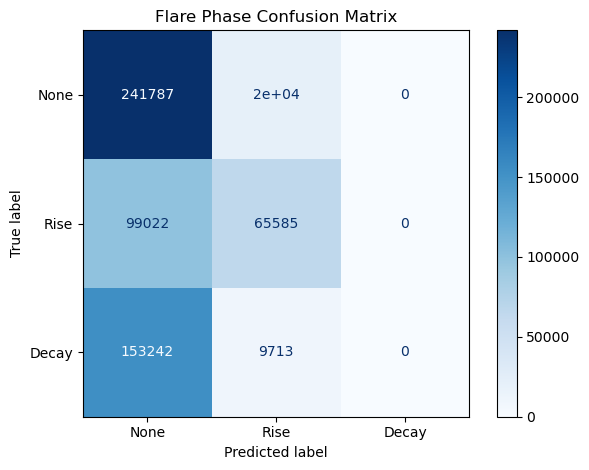

In [214]:
# Evaluate the Model
model.eval() # ensure model is in eval mode when using in-memory model
# Can also load in a model saved on disk along with the _config.json file that was saved alongside the model using model=None and model_path= path from above 
evaluate_model(model,
               dataset_path=data_path,
               split_path=split_path,
               visualize=True,
               save_report=True,
               output_dir=output_dir,
               batch_size=batch_size,
               seq_len=seq_len)


# Debugging and Testing

Includes this to move to analysis/utils

* function to plot these synthetic flares (3 graphs)
* Evaluate class imbalance (e.g., how often 1 or 2 appear vs 0).
* Other EDA stuff I already did 

In [58]:
# Use a representative light curve (replace with actual TIC ID if needed)
times = synthetic_lightcurves[117955697]["time"]  # or your loaded time array

# Check average cadence
dt = np.diff(times)
print("Mean cadence in days:", np.mean(dt))
print("Mean cadence in minutes:", np.mean(dt) * 24 * 60)

Mean cadence in days: 0.0013891367859354957
Mean cadence in minutes: 2.000356971747114


✅ Top Plot: Original Flux (black) vs Smoothed Baseline (red)
The red line (Savitzky-Golay filter) is doing a nice job tracking the underlying shape.

Flares appear as sharp upward spikes that poke above the red baseline.

✅ Middle Plot: Flare-only Signal (blue)
This is synthetic_flux - baseline → isolating the flare signal.

Most of the values hover around 0 (normal flux), but flare events now pop out as positive spikes.


## explanation
The underlying detrended light curve (i.e., the real signal without flares) has natural variability — it's not flat.

When we add synthetic flares on top, the flare signal is added to the existing flux. So:

If a flare is injected onto a falling baseline, the flare's rising shape is “tilted down”.

If a flare is injected onto a rising baseline, the decay shape may slope upward.

This doesn’t mean the flare is labeled incorrectly — it just means the flare sits on a wobbly floor.

Your labeling is correct — it’s just that real light curves aren’t flat.
This behavior is expected when injecting flares on top of real or semi-real light curves.


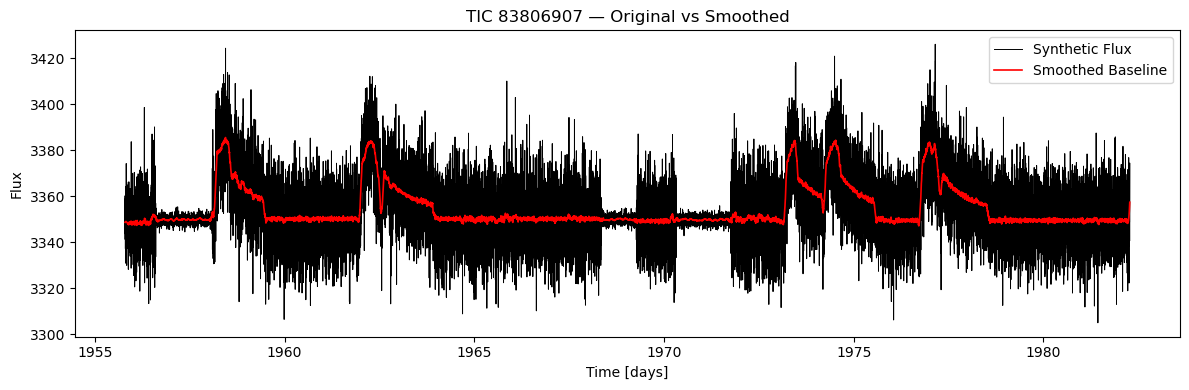

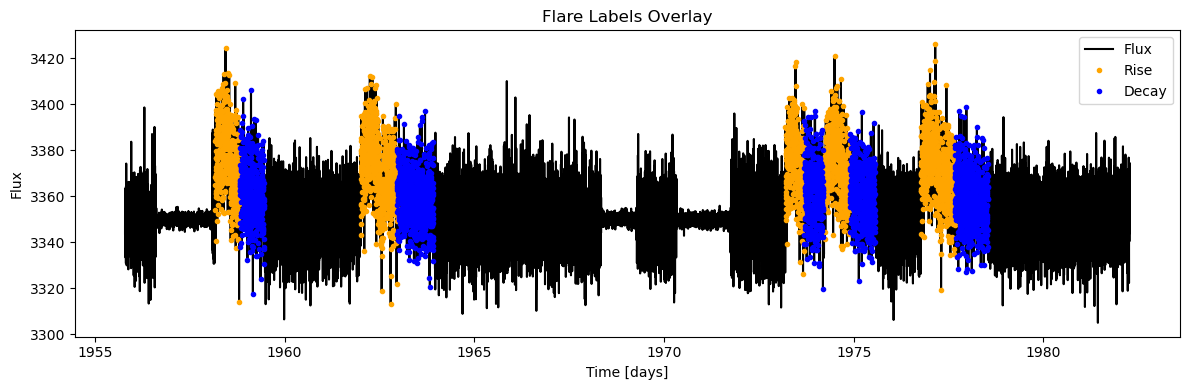

In [200]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter


# --- Pick one TIC ID ---
example_tic = list(synthetic_lightcurves.keys())[5]
example = synthetic_lightcurves[example_tic]

# --- Extract data ---
time = example["time"]
flux = example["synthetic_flux"]
binary_labels = example["flare_binary_labels"]
phase_labels = example["flare_phase_labels"]

# --- Smooth baseline with Savitzky-Golay filter ---
baseline = savgol_filter(flux, window_length=101, polyorder=3)
#flare_only = flux - baseline

# --- Plot original vs smoothed ---
plt.figure(figsize=(12, 4))
plt.plot(time, flux, color='black', linewidth=0.7, label='Synthetic Flux')
plt.plot(time, baseline, color='red', linewidth=1.2, label='Smoothed Baseline')
plt.title(f"TIC {example_tic} — Original vs Smoothed")
plt.xlabel("Time [days]")
plt.ylabel("Flux")
plt.legend()
plt.tight_layout()
plt.show()

# # --- Plot flare-only signal ---
# plt.figure(figsize=(12, 4))
# plt.plot(time, flare_only, color='blue', linewidth=0.8)
# plt.title(f"TIC {example_tic} — Flare-only Signal (Flux - Baseline)")
# plt.xlabel("Time [days]")
# plt.ylabel("Flare Flux")
# plt.tight_layout()
# plt.show()

# Overlay phase labels (1 = rise, 2 = decay)
rise_times = time[np.array(phase_labels) == 1]
rise_flux = flux[np.array(phase_labels) == 1]

decay_times = time[np.array(phase_labels) == 2]
decay_flux = flux[np.array(phase_labels) == 2]

plt.figure(figsize=(12, 4))
plt.plot(time, flux, 'k', label="Flux")
plt.plot(rise_times, rise_flux, 'orange', linestyle='None', marker='o', markersize=3, label="Rise")
plt.plot(decay_times, decay_flux, 'blue', linestyle='None', marker='o', markersize=3, label="Decay")
plt.legend()
plt.title("Flare Labels Overlay")
plt.xlabel("Time [days]")
plt.ylabel("Flux")
plt.tight_layout()
plt.show()


In [204]:
print(len(example["synthetic_flux"]))

18894
